In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from google.cloud import storage
import io
from orchestrator import Orchestrator
import cProfile
import asyncio
import pstats
import io
import sys
sys.path.append("..")

from creds import MAPPER_URL, REDUCER_URL

In [5]:
bucket_name = "jack-fall2024"


In [4]:
# Generate Matrices
Matrix_A = np.random.randint(0, 10, (10, 10))  
Matrix_B = np.random.randint(0, 10, (10, 10)) 

# Initialize Google Cloud Storage client
client = storage.Client()
bucket = client.bucket(bucket_name)

def upload_matrix_to_gcs(matrix, matrix_name):
    matrix_bytes = io.BytesIO()
    np.save(matrix_bytes, matrix)
    matrix_bytes.seek(0) 

    blob = bucket.blob(f"{matrix_name}.npy")

    blob.upload_from_file(matrix_bytes, content_type='application/octet-stream')
    print(f"Uploaded {matrix_name} to {bucket_name}.")

# Upload both matrices
upload_matrix_to_gcs(Matrix_A, "Matrix_A")
upload_matrix_to_gcs(Matrix_B, "Matrix_B")




Uploaded Matrix_A to jack-fall2024.
Uploaded Matrix_B to jack-fall2024.


In [5]:
print(Matrix_A)

[[6 1 4 1 5 1 1 4 6 6]
 [1 3 0 7 8 7 0 9 6 8]
 [6 3 4 2 6 4 5 1 3 0]
 [2 7 8 0 3 4 4 5 3 6]
 [7 5 3 6 8 7 5 8 4 4]
 [9 4 4 3 3 3 9 0 2 9]
 [1 8 1 6 0 1 3 4 3 0]
 [5 9 4 2 0 8 6 8 6 7]
 [2 8 7 8 8 4 1 2 5 3]
 [8 4 5 2 8 9 0 0 0 0]]


In [6]:
print(Matrix_B)

[[8 3 7 5 8 7 6 8 7 6]
 [3 9 3 4 0 9 9 3 9 7]
 [4 8 9 2 9 2 6 1 1 0]
 [3 7 9 9 1 1 3 6 0 0]
 [9 2 5 2 7 8 2 7 4 9]
 [8 2 2 5 9 1 7 8 4 6]
 [3 7 6 7 9 5 8 6 9 5]
 [1 8 0 4 4 1 9 0 1 2]
 [6 9 2 6 7 1 7 4 1 0]
 [8 7 2 8 3 7 4 5 0 1]]


In [7]:

print(np.matmul(Matrix_A, Matrix_B))

[[214 213 147 173 214 158 199 164  98 113]
 [275 291 161 267 236 183 274 235 109 167]
 [199 181 179 157 234 160 203 189 162 162]
 [211 284 172 194 240 191 279 164 157 148]
 [308 325 245 289 325 242 344 288 214 236]
 [271 272 235 264 281 247 272 258 210 181]
 [ 93 207 120 153  96 110 190 107 118  91]
 [271 367 194 293 299 227 387 242 220 194]
 [255 303 243 233 240 209 267 224 157 176]
 [246 148 189 145 248 177 199 221 165 202]]


In [ ]:

block_size = 15
orch = Orchestrator(Matrix_A, Matrix_B, block_size, MAPPER_URL, REDUCER_URL, bucket_name)

start_time = time.time() 
map_result, _, _ = await orch.orchestrate_matrix_multiplication()
name = 'final_matrix.npy'
orch.save_to_bucket(map_result, name)
print(map_result)

[[214. 213. 147. 173. 214. 158. 199. 164.  98. 113.]
 [275. 291. 161. 267. 236. 183. 274. 235. 109. 167.]
 [199. 181. 179. 157. 234. 160. 203. 189. 162. 162.]
 [211. 284. 172. 194. 240. 191. 279. 164. 157. 148.]
 [308. 325. 245. 289. 325. 242. 344. 288. 214. 236.]
 [271. 272. 235. 264. 281. 247. 272. 258. 210. 181.]
 [ 93. 207. 120. 153.  96. 110. 190. 107. 118.  91.]
 [271. 367. 194. 293. 299. 227. 387. 242. 220. 194.]
 [255. 303. 243. 233. 240. 209. 267. 224. 157. 176.]
 [246. 148. 189. 145. 248. 177. 199. 221. 165. 202.]]


In [21]:
dim = 50
blocksizes = [1, 2, 5, 10, 15, 20, 25, 50]
results = []
for blocksize in blocksizes:
    Matrix_A = np.random.randint(0, 10, (dim, dim))
    Matrix_B = np.random.randint(0, 10, (dim, dim))


    orch = Orchestrator(Matrix_A, Matrix_B, blocksize, MAPPER_URL, REDUCER_URL, bucket_name)

    start_time = time.time()
    map_result, _, _ = await orch.orchestrate_matrix_multiplication()
    results.append(time.time() - start_time)

[67.588543176651, 40.616724491119385, 11.917519330978394, 7.8418800830841064, 5.517728805541992, 3.89923095703125, 3.4565258026123047, 1.6261467933654785]


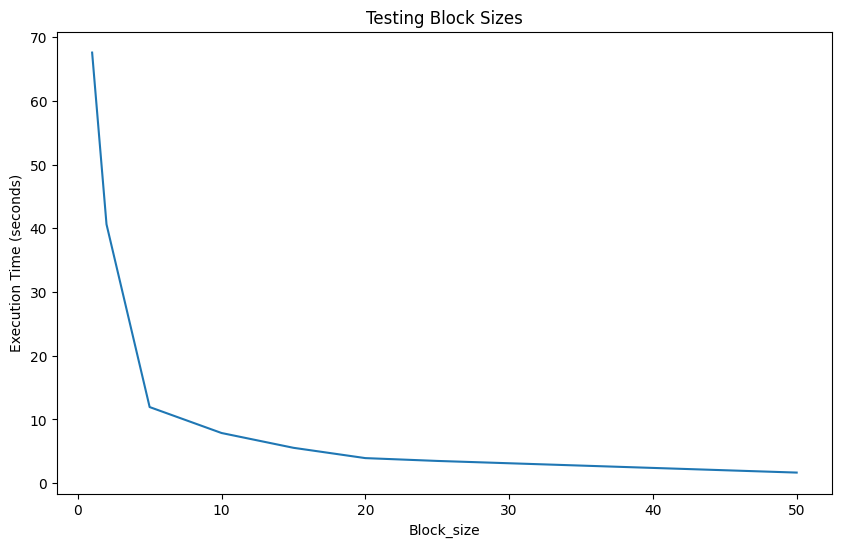

In [23]:

print(results)
plt.figure(figsize=(10, 6))
plt.plot(blocksizes, results)
plt.xlabel('Block_size')
plt.ylabel('Execution Time (seconds)')
plt.title('Testing Block Sizes')
plt.show()

In [16]:
numpy_times = []
mapreduce_times = []
dimensions = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
blocksize = 15
for dim in dimensions:
    # Create random matrices
    Matrix_A = np.random.randint(0, 10, (dim, dim))
    Matrix_B = np.random.randint(0, 10, (dim, dim))
    
    start_time = time.time()
    np.matmul(Matrix_A, Matrix_B)
    numpy_times.append(time.time() - start_time)

    orch = Orchestrator(Matrix_A, Matrix_B, blocksize, MAPPER_URL, REDUCER_URL, bucket_name)

    start_time = time.time()
    map_result, _, _ = await orch.orchestrate_matrix_multiplication()

    mapreduce_times.append(time.time() - start_time)



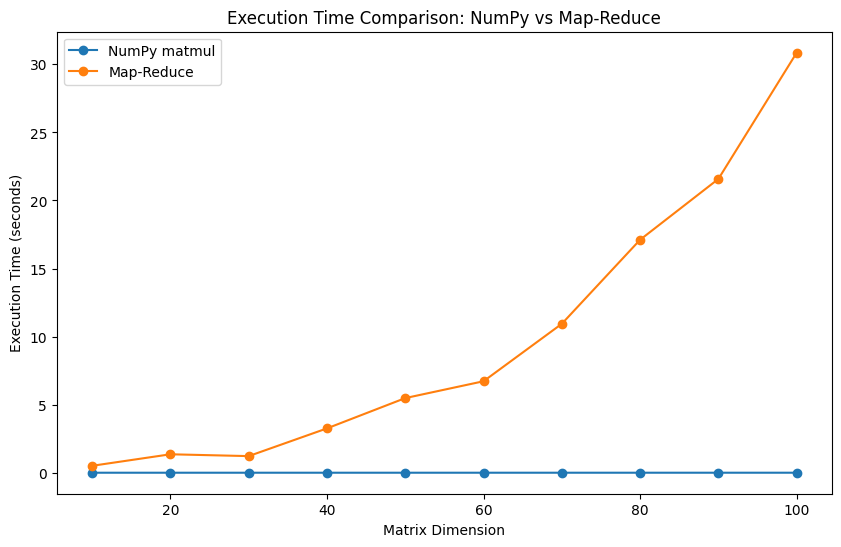

In [ ]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(dimensions, numpy_times, label='NumPy matmul', marker='o')
plt.plot(dimensions, mapreduce_times, label='Map-Reduce', marker='o')
plt.xlabel('Matrix Dimension')
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time Comparison: NumPy vs Map-Reduce')
plt.legend()
plt.show()

In [18]:
numpy_times = []
map_times = []
reduce_times = []
dimensions = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
blocksize = 15
for dim in dimensions:
    # Create random matrices
    Matrix_A = np.random.randint(0, 10, (dim, dim))
    Matrix_B = np.random.randint(0, 10, (dim, dim))


    orch = Orchestrator(Matrix_A, Matrix_B, blocksize, MAPPER_URL, REDUCER_URL, bucket_name)

    _, map_result, reduce_result = await orch.orchestrate_matrix_multiplication()

    map_times.append(map_result)
    reduce_times.append(reduce_result)



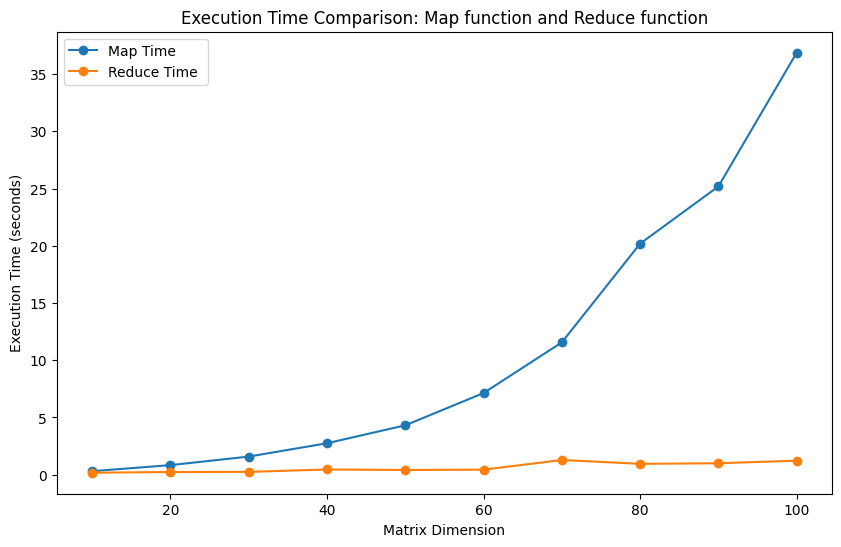

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(dimensions, map_times, label='Map Time', marker='o')
plt.plot(dimensions, reduce_times, label='Reduce Time ', marker='o')
plt.xlabel('Matrix Dimension')
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time Comparison: Map function and Reduce function')
plt.legend()
plt.show()